# Market microstructure research with synthetic L2 data

This notebook demonstrates a complete, leakage-aware research workflow: generate
deterministic synthetic order-book snapshots, engineer causal features, define a
future-return target, fit a chronological baseline, and evaluate a cost-aware signal.

The data and implementation are clean-room and research-only. No employer data,
brokerage connection, or live-trading claim is included.


## Research question

Can transparent order-book features such as depth imbalance, a static weighted
mid-price, and order-flow imbalance recover a deliberately embedded signal in a
synthetic market? This is a software validation exercise, not a profitability claim.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from market_microstructure.backtest import run_backtest
from market_microstructure.features import engineer_features
from market_microstructure.labels import add_future_move_label
from market_microstructure.models import (
    FEATURE_COLUMNS, build_baseline, chronological_split, classification_metrics
)
from market_microstructure.synthetic import SyntheticLOBConfig, generate_synthetic_lob


## 1. Generate and inspect synthetic order-book snapshots

In [2]:
raw = generate_synthetic_lob(SyntheticLOBConfig(rows=6_000, seed=42))
raw.head()


,timestamp,mid_price,bid_price_1,ask_price_1,bid_size_1,ask_size_1,bid_price_2,ask_price_2,bid_size_2,ask_size_2,...,ask_price_4,bid_size_4,ask_size_4,bid_price_5,ask_price_5,bid_size_5,ask_size_5,aggressor_side,trade_price,trade_size
0,2026-01-02T09:30:00+00:00,100.00,99.995,100.005,26.170,36.602,99.985,100.015,60.749,64.734,...,100.035,132.268,132.888,99.955,100.045,96.161,141.230,-1,99.995,14.855
1,2026-01-02T09:30:01+00:00,100.00,99.990,100.010,46.195,66.043,99.980,100.020,76.327,98.346,...,100.040,67.619,92.457,99.950,100.050,79.262,102.098,-1,99.990,24.749
2,2026-01-02T09:30:02+00:00,100.00,99.990,100.010,63.123,78.116,99.980,100.020,80.160,85.237,...,100.040,74.474,83.513,99.950,100.050,106.021,91.388,-1,99.990,6.517
3,2026-01-02T09:30:03+00:00,100.00,99.995,100.005,80.741,83.454,99.985,100.015,64.081,66.975,...,100.035,102.980,130.373,99.955,100.045,84.273,105.658,1,100.005,21.141
4,2026-01-02T09:30:04+00:00,100.01,100.000,100.020,61.526,84.021,99.990,100.030,79.498,105.191,...,100.050,39.514,51.695,99.960,100.060,68.625,75.627,1,100.020,33.602


In [3]:
raw[["mid_price", "bid_price_1", "ask_price_1", "bid_size_1", "ask_size_1"]].describe()


,mid_price,bid_price_1,ask_price_1,bid_size_1,ask_size_1
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,99.452095,99.445419,99.458771,65.827732,68.562066
std,0.375710,0.375719,0.375723,28.279124,29.325258
min,98.780000,98.765000,98.785000,12.449000,13.880000
25%,99.070000,99.065000,99.075000,46.156250,47.567000
50%,99.520000,99.505000,99.525000,60.551500,62.925000
75%,99.770000,99.755000,99.775000,79.411250,83.778750
max,100.100000,100.095000,100.105000,271.543000,259.508000


## 2. Engineer causal features and targets

Feature calculations use the current and earlier snapshots only. The target is
constructed in a separate step from the future mid-price and is never included in
the feature matrix.


In [4]:
featured = engineer_features(raw, levels=5, rolling_window=20)
labeled = add_future_move_label(featured, horizon=10, threshold_bps=0.5)
model_frame = labeled.dropna(subset=FEATURE_COLUMNS + ["target"]).copy()
model_frame["target"] = model_frame["target"].astype(int)
model_frame[FEATURE_COLUMNS + ["target"]].head()


,relative_spread_bps,top_imbalance,weighted_midprice_distance_bps,depth_imbalance,top_depth_concentration,order_flow_imbalance,signed_trade_flow,momentum,rolling_volatility,rolling_ofi,target
20,0.9999,-0.005272,-0.002636,-0.116248,0.144436,21.839,-11.859,0.0001,0.000039,241.240,-1
21,0.9998,-0.351376,-0.175653,-0.279374,0.271804,127.008,34.000,0.0002,0.000045,357.816,-1
22,0.9998,-0.212742,-0.106350,-0.268442,0.113079,50.361,5.259,0.0002,0.000045,403.322,-1
23,0.9999,-0.366587,-0.183275,-0.335197,0.194350,-172.009,-15.939,0.0001,0.000051,234.026,-1
24,0.9999,-0.306534,-0.153252,-0.239736,0.122420,33.418,3.220,0.0000,0.000046,122.464,-1


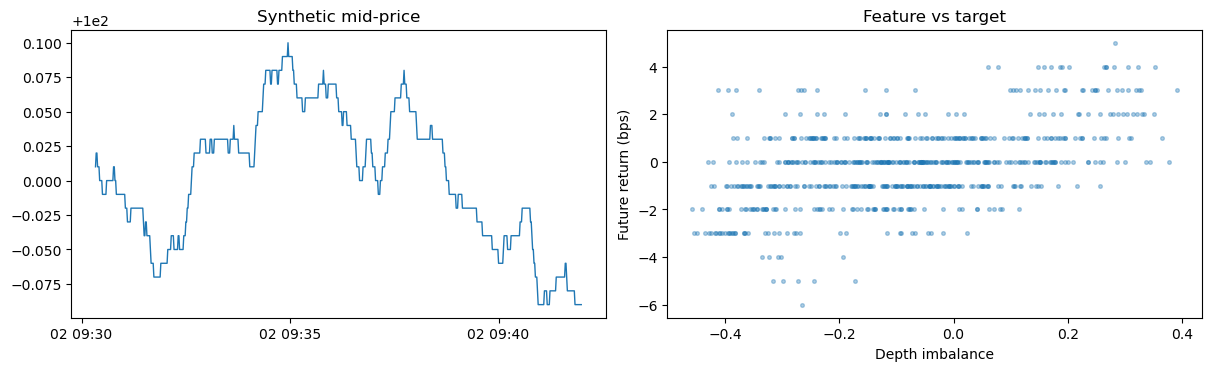

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
sample = model_frame.iloc[:700]
axes[0].plot(sample["timestamp"], sample["mid_price"], linewidth=1)
axes[0].set_title("Synthetic mid-price")
axes[1].scatter(sample["depth_imbalance"], sample["future_return_bps"], s=7, alpha=0.35)
axes[1].set(xlabel="Depth imbalance", ylabel="Future return (bps)", title="Feature vs target")
plt.show()


## 3. Train and evaluate chronologically

Random splitting would leak later market regimes into training. The final 25 percent
of observations are held out in time order.


In [6]:
split = chronological_split(model_frame, test_fraction=0.25)
model = build_baseline(random_state=42)
model.fit(split.train[FEATURE_COLUMNS], split.train["target"])
predictions = pd.Series(model.predict(split.test[FEATURE_COLUMNS]), index=split.test.index)
classification_metrics(split.test["target"], predictions)


{'accuracy': 0.5003348961821835,
 'balanced_accuracy': 0.4661746078628847,
 'macro_f1': 0.44827492480510706,
 'confusion_matrix': [[230, 66, 181], [99, 67, 256], [74, 70, 450]],
 'label_order': [-1, 0, 1]}

## 4. Apply signals with delay and costs

A prediction at snapshot t becomes a position at t+1. Turnover is charged one basis
point. The simplified backtest excludes latency, queue priority, fill uncertainty,
market impact, fees by venue, and risk constraints.


In [7]:
backtest, backtest_metrics = run_backtest(
    split.test["mid_price"], predictions, transaction_cost_bps=1.0
)
backtest_metrics


{'total_return': -0.02272592393638928,
 'gross_total_return': 0.01097370047528523,
 'max_drawdown': -0.023914554599053672,
 'turnover': 339.0,
 'hit_rate_active': 0.1474010861132661,
 'transaction_cost_bps': 1.0}

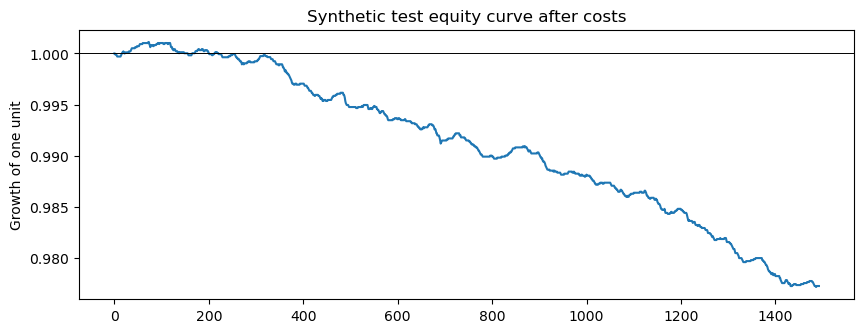

In [8]:
backtest["equity_curve"].plot(figsize=(10, 3.5), title="Synthetic test equity curve after costs")
plt.axhline(1.0, color="black", linewidth=0.7)
plt.ylabel("Growth of one unit")
plt.show()


## Limitations and next steps

Synthetic predictability validates the pipeline, not a market edge. A serious study
would require licensed data, walk-forward validation, richer execution modeling,
regime robustness checks, probability calibration, and explicit risk limits.

See REFERENCES.md for the academic background and DATA_POLICY.md for safe-data rules.
